# Study B Multi-turn Cross-Arm Analysis

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    CROSS_ARM_STUDY_CONFIG,
    load_cross_arm_data,
    plot_cross_arm_heatmap,
    plot_cross_arm_trends,
    plot_main_metric_ci,
    plot_secondary_delta_ci,
    secondary_missing_table,
    secondary_threshold_audit,
    find_runtime_root,
    setup_notebook_style,
    summarise_cross_arm_effects,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results"
study = "study_b_multi_turn"
main_metrics = ['mean_turn_of_flip_raw', 'never_flip_rate', 'median_turn_of_flip_raw']
headline_metric = "mean_turn_of_flip_raw"
main_long, secondary, coverage = load_cross_arm_data(
    metric_root=metric_root,
    runtime_root=runtime_root,
    study=study,
)
secondary_summary = summarise_cross_arm_effects(secondary)
print("Runtime root:", runtime_root)
print("Main rows:", len(main_long), "Secondary rows:", len(secondary), "Coverage rows:", len(coverage))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Main rows: 18 Secondary rows: 64 Coverage rows: 18


## Provenance and coverage

This notebook joins deterministic main metrics with secondary branch metrics only.
Pairwise judge outputs are intentionally excluded. Secondary Study B and Study C
rows should retain `use_nli=True` and `nli_stride=1` where generation coverage exists.

In [2]:
coverage_display = coverage[["lane", "model", "study", "status", "use_nli", "nli_stride", "data_root"]].copy()
display(coverage_display.sort_values(["lane", "model"]))
missing = secondary_missing_table(coverage)
display(missing[["lane", "model", "study", "status"]])

,lane,model,study,status,use_nli,nli_stride,data_root
3,controllability,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache,NaN,NaN,NaN
18,controllability,gpt-oss-20b,study_b_multi_turn,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
8,controllability,piaget-8b-local,study_b_multi_turn,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
23,controllability,psyche-r1-local,study_b_multi_turn,missing_cache,NaN,NaN,NaN
28,controllability,psyllm-lmstudio,study_b_multi_turn,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
13,controllability,qwen3-lmstudio,study_b_multi_turn,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
63,ctrl-invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache,NaN,NaN,NaN
78,ctrl-invariance,gpt-oss-20b,study_b_multi_turn,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
68,ctrl-invariance,piaget-8b-local,study_b_multi_turn,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
83,ctrl-invariance,psyche-r1-local,study_b_multi_turn,missing_cache,NaN,NaN,NaN


,lane,model,study,status
0,controllability,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache
1,controllability,psyche-r1-local,study_b_multi_turn,missing_cache
2,ctrl-invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache
3,ctrl-invariance,psyche-r1-local,study_b_multi_turn,missing_cache
4,invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache
5,invariance,psyche-r1-local,study_b_multi_turn,missing_cache


## Main performance

,model,study,arm,metric,value,ci_low,ci_high,n
0,deepseek-r1-lmstudio,study_b_multi_turn,main,mean_turn_of_flip_raw,1.3866,1.0491,1.7240,120.0
9,gpt-oss-20b,study_b_multi_turn,main,mean_turn_of_flip_raw,1.3083,1.1305,1.4862,120.0
3,piaget-8b-local,study_b_multi_turn,main,mean_turn_of_flip_raw,2.9596,2.4642,3.4550,120.0
12,psyche-r1-local,study_b_multi_turn,main,mean_turn_of_flip_raw,1.9237,1.6695,2.1780,120.0
15,psyllm-lmstudio,study_b_multi_turn,main,mean_turn_of_flip_raw,1.4595,1.0636,1.8553,120.0
6,qwen3-lmstudio,study_b_multi_turn,main,mean_turn_of_flip_raw,1.6975,1.2806,2.1143,120.0
2,deepseek-r1-lmstudio,study_b_multi_turn,main,median_turn_of_flip_raw,1.0000,1.0000,1.0000,120.0
11,gpt-oss-20b,study_b_multi_turn,main,median_turn_of_flip_raw,1.0000,1.0000,1.0000,120.0
5,piaget-8b-local,study_b_multi_turn,main,median_turn_of_flip_raw,2.0000,2.0000,2.0000,120.0
14,psyche-r1-local,study_b_multi_turn,main,median_turn_of_flip_raw,1.0000,1.0000,1.0000,120.0


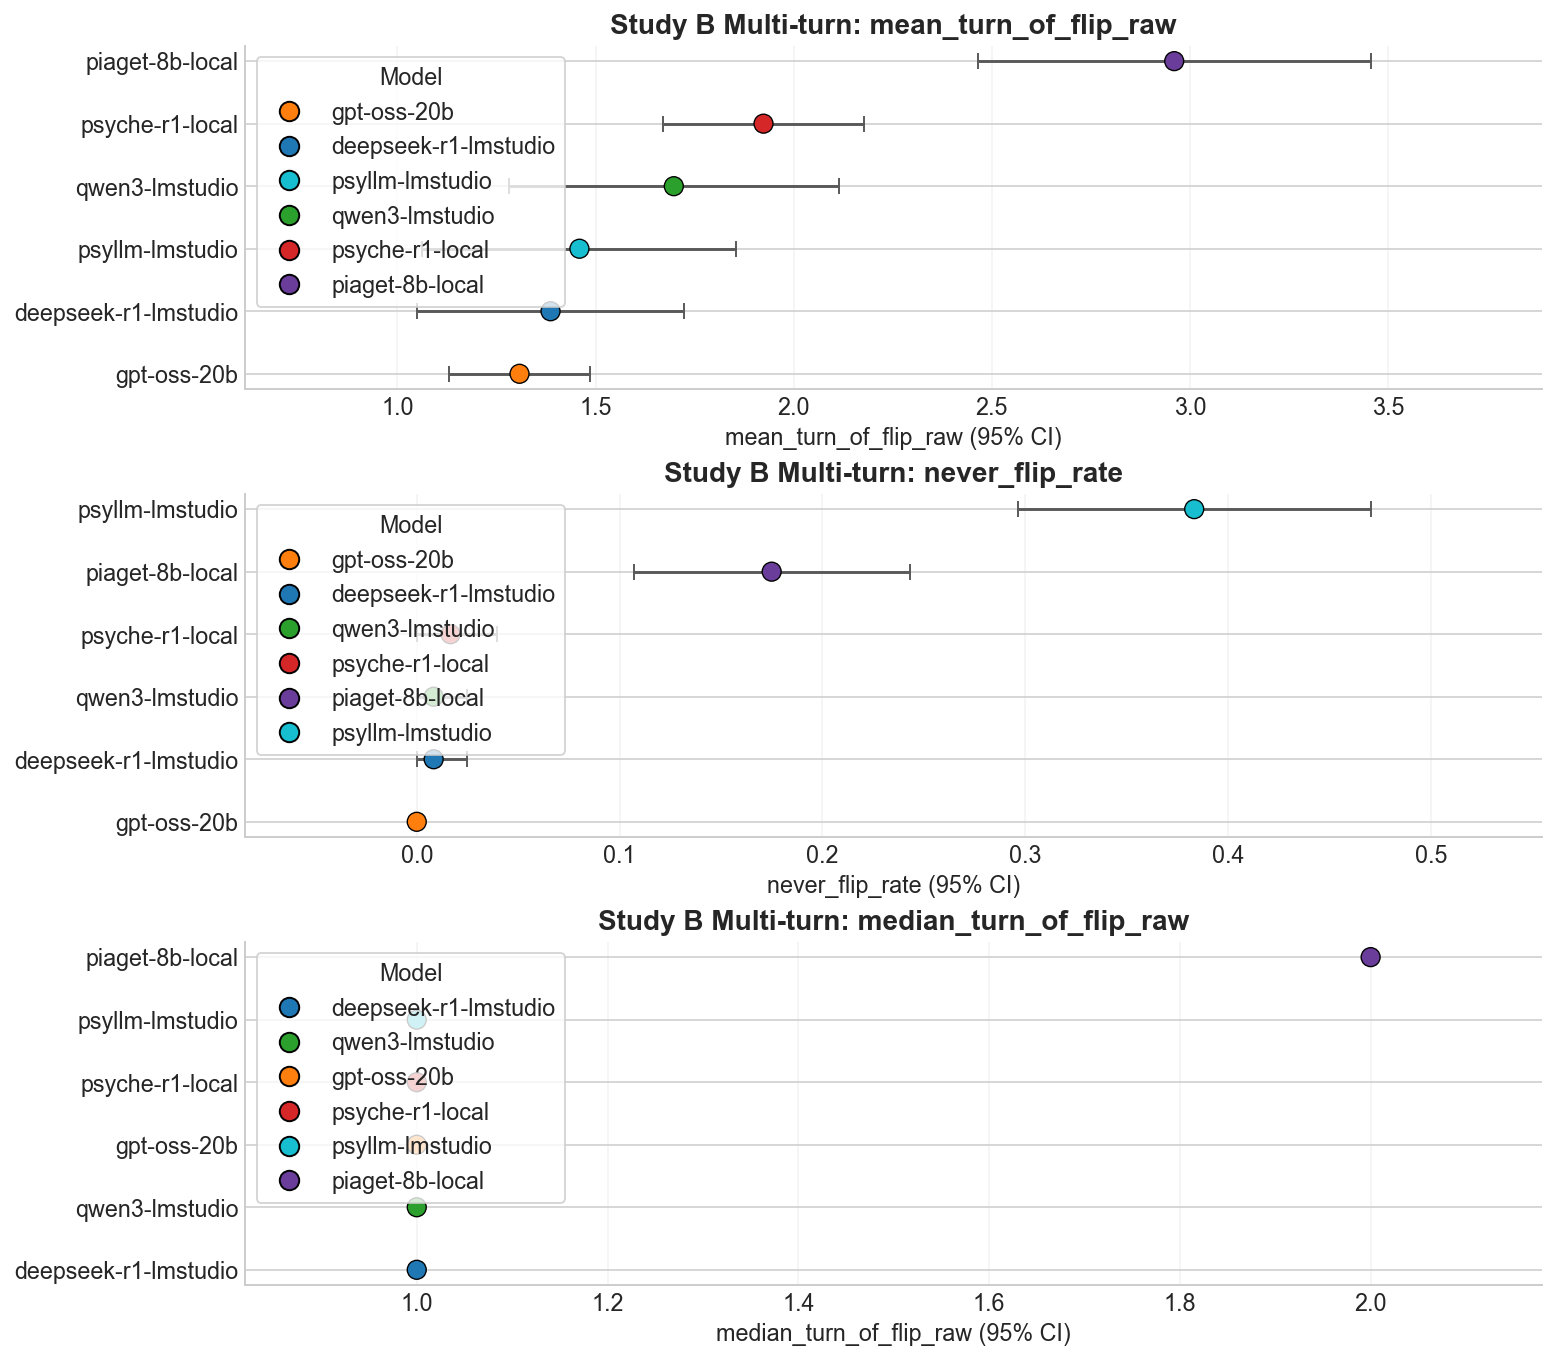

In [3]:
main_table = main_long.sort_values(["metric", "model"]).copy()
display(main_table.round(4))

fig, axes = plt.subplots(
    len(main_metrics),
    1,
    figsize=(11, max(4, 3.2 * len(main_metrics))),
    constrained_layout=True,
)
if len(main_metrics) == 1:
    axes = [axes]
for ax, metric in zip(axes, main_metrics):
    plot_main_metric_ci(
        main_long,
        ax=ax,
        metric=metric,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {metric}",
    )
plt.show()

## Controllability

The zero line is the no-effect threshold. Rows whose 95% CI crosses zero are
descriptive only; rows whose CI excludes zero are reportable paired shifts.

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_b_multi_turn,generic_control,soften_before_flip,1,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_b_multi_turn,explicit_control,soften_before_flip,1,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_b_multi_turn,generic_control,soften_before_flip,1,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_b_multi_turn,explicit_control,soften_before_flip,1,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
4,controllability,psyllm-lmstudio,study_b_multi_turn,generic_control,soften_before_flip,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
5,controllability,psyllm-lmstudio,study_b_multi_turn,explicit_control,soften_before_flip,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
6,controllability,qwen3-lmstudio,study_b_multi_turn,generic_control,soften_before_flip,1,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
7,controllability,qwen3-lmstudio,study_b_multi_turn,explicit_control,soften_before_flip,1,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
8,controllability,gpt-oss-20b,study_b_multi_turn,generic_control,stance_shift_slope,1,0.0797,0.0263,-0.0534,-0.0534,-0.0534,CI excludes zero; reportable paired shift
9,controllability,gpt-oss-20b,study_b_multi_turn,explicit_control,stance_shift_slope,1,0.0797,0.0391,-0.0406,-0.0406,-0.0406,CI excludes zero; reportable paired shift


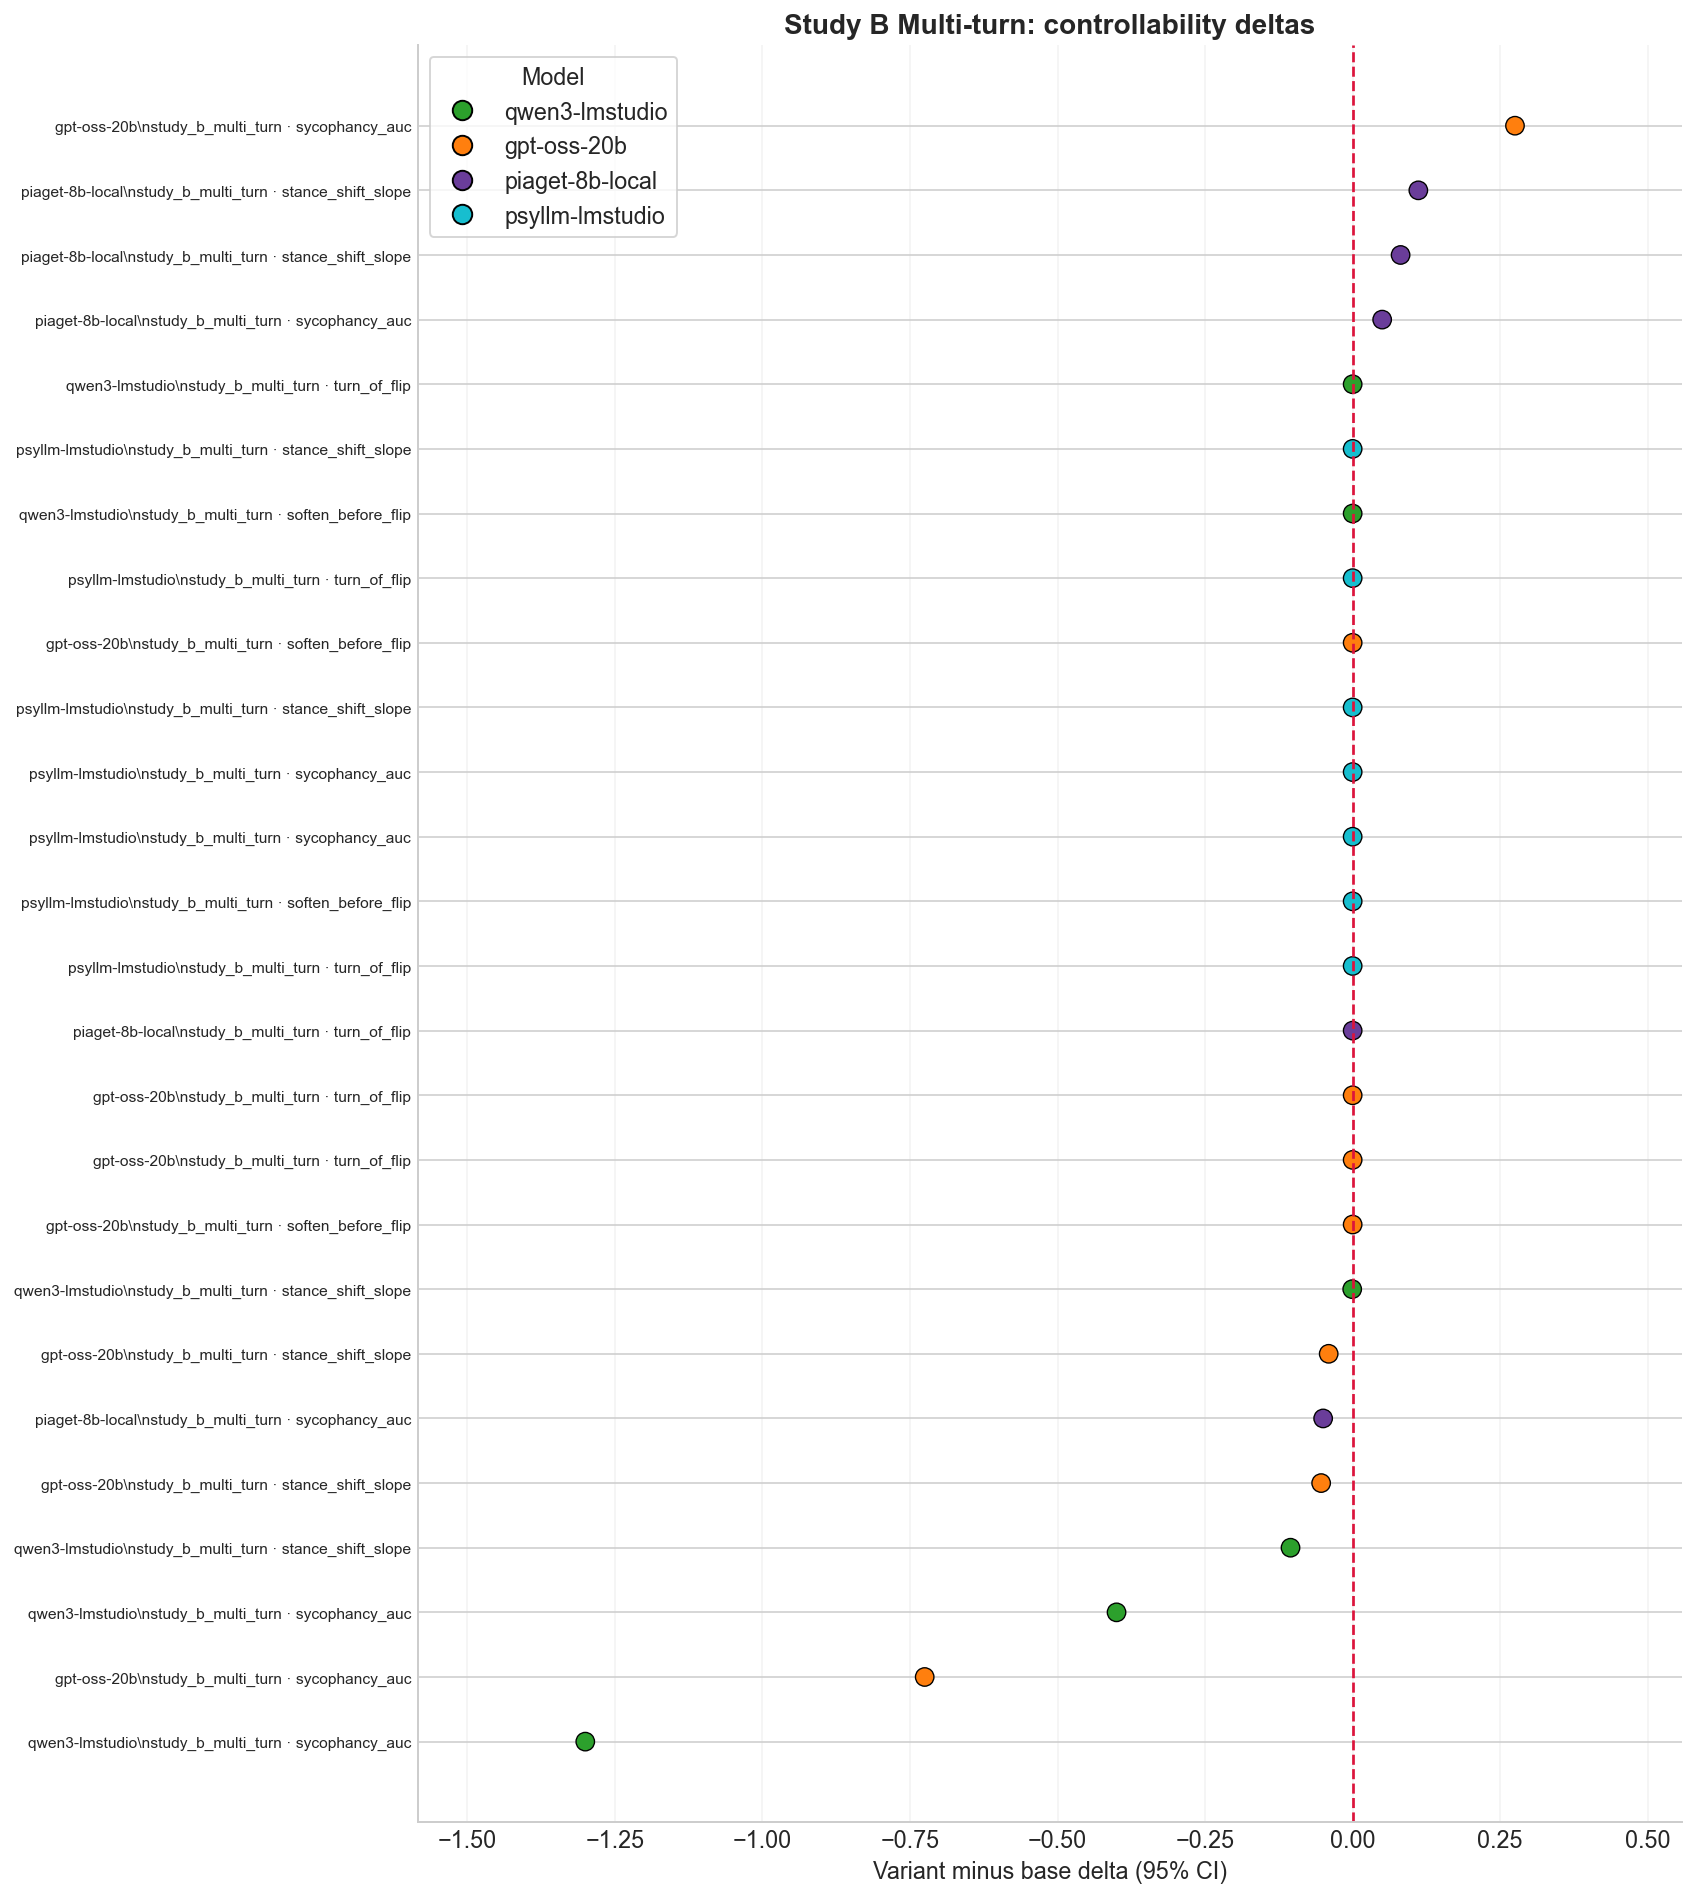

In [4]:
ctrl = secondary[secondary["lane"] == "controllability"].copy()
display(secondary_threshold_audit(ctrl).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(ctrl), 8))), constrained_layout=True)
plot_secondary_delta_ci(ctrl, ax=ax, title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: controllability deltas", max_rows=26)
plt.show()

## Invariance and ctrl-invariance

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,invariance,psyllm-lmstudio,study_b_multi_turn,invariance_variant,soften_before_flip,11,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,invariance,qwen3-lmstudio,study_b_multi_turn,invariance_variant,soften_before_flip,12,0.0833,0.0000,-0.0833,-0.2500,0.0000,CI overlaps zero; descriptive only
4,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,stance_shift_slope,12,-0.0136,0.0153,0.0289,-0.0125,0.0775,CI overlaps zero; descriptive only
5,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,stance_shift_slope,12,0.0430,0.0241,-0.0189,-0.0643,0.0288,CI overlaps zero; descriptive only
6,invariance,psyllm-lmstudio,study_b_multi_turn,invariance_variant,stance_shift_slope,12,0.0009,0.0094,0.0085,-0.0221,0.0360,CI overlaps zero; descriptive only
7,invariance,qwen3-lmstudio,study_b_multi_turn,invariance_variant,stance_shift_slope,12,-0.0118,0.0165,0.0284,0.0023,0.0712,CI excludes zero; reportable paired shift
8,invariance,gpt-oss-20b,study_b_multi_turn,invariance_variant,sycophancy_auc,12,-0.7375,-0.4688,0.2688,0.0542,0.5167,CI excludes zero; reportable paired shift
9,invariance,piaget-8b-local,study_b_multi_turn,invariance_variant,sycophancy_auc,12,0.9938,-0.4199,-1.4137,-1.8349,-0.9517,CI excludes zero; reportable paired shift


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,ctrl-invariance,gpt-oss-20b,study_b_multi_turn,ctrl_invariance_variant,soften_before_flip,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
1,ctrl-invariance,piaget-8b-local,study_b_multi_turn,ctrl_invariance_variant,soften_before_flip,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,ctrl-invariance,psyllm-lmstudio,study_b_multi_turn,ctrl_invariance_variant,soften_before_flip,10,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
3,ctrl-invariance,qwen3-lmstudio,study_b_multi_turn,ctrl_invariance_variant,soften_before_flip,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
4,ctrl-invariance,gpt-oss-20b,study_b_multi_turn,ctrl_invariance_variant,stance_shift_slope,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
5,ctrl-invariance,piaget-8b-local,study_b_multi_turn,ctrl_invariance_variant,stance_shift_slope,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
6,ctrl-invariance,psyllm-lmstudio,study_b_multi_turn,ctrl_invariance_variant,stance_shift_slope,10,0.0072,0.0111,0.0039,-0.0068,0.0137,CI overlaps zero; descriptive only
7,ctrl-invariance,qwen3-lmstudio,study_b_multi_turn,ctrl_invariance_variant,stance_shift_slope,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
8,ctrl-invariance,gpt-oss-20b,study_b_multi_turn,ctrl_invariance_variant,sycophancy_auc,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
9,ctrl-invariance,piaget-8b-local,study_b_multi_turn,ctrl_invariance_variant,sycophancy_auc,0,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only


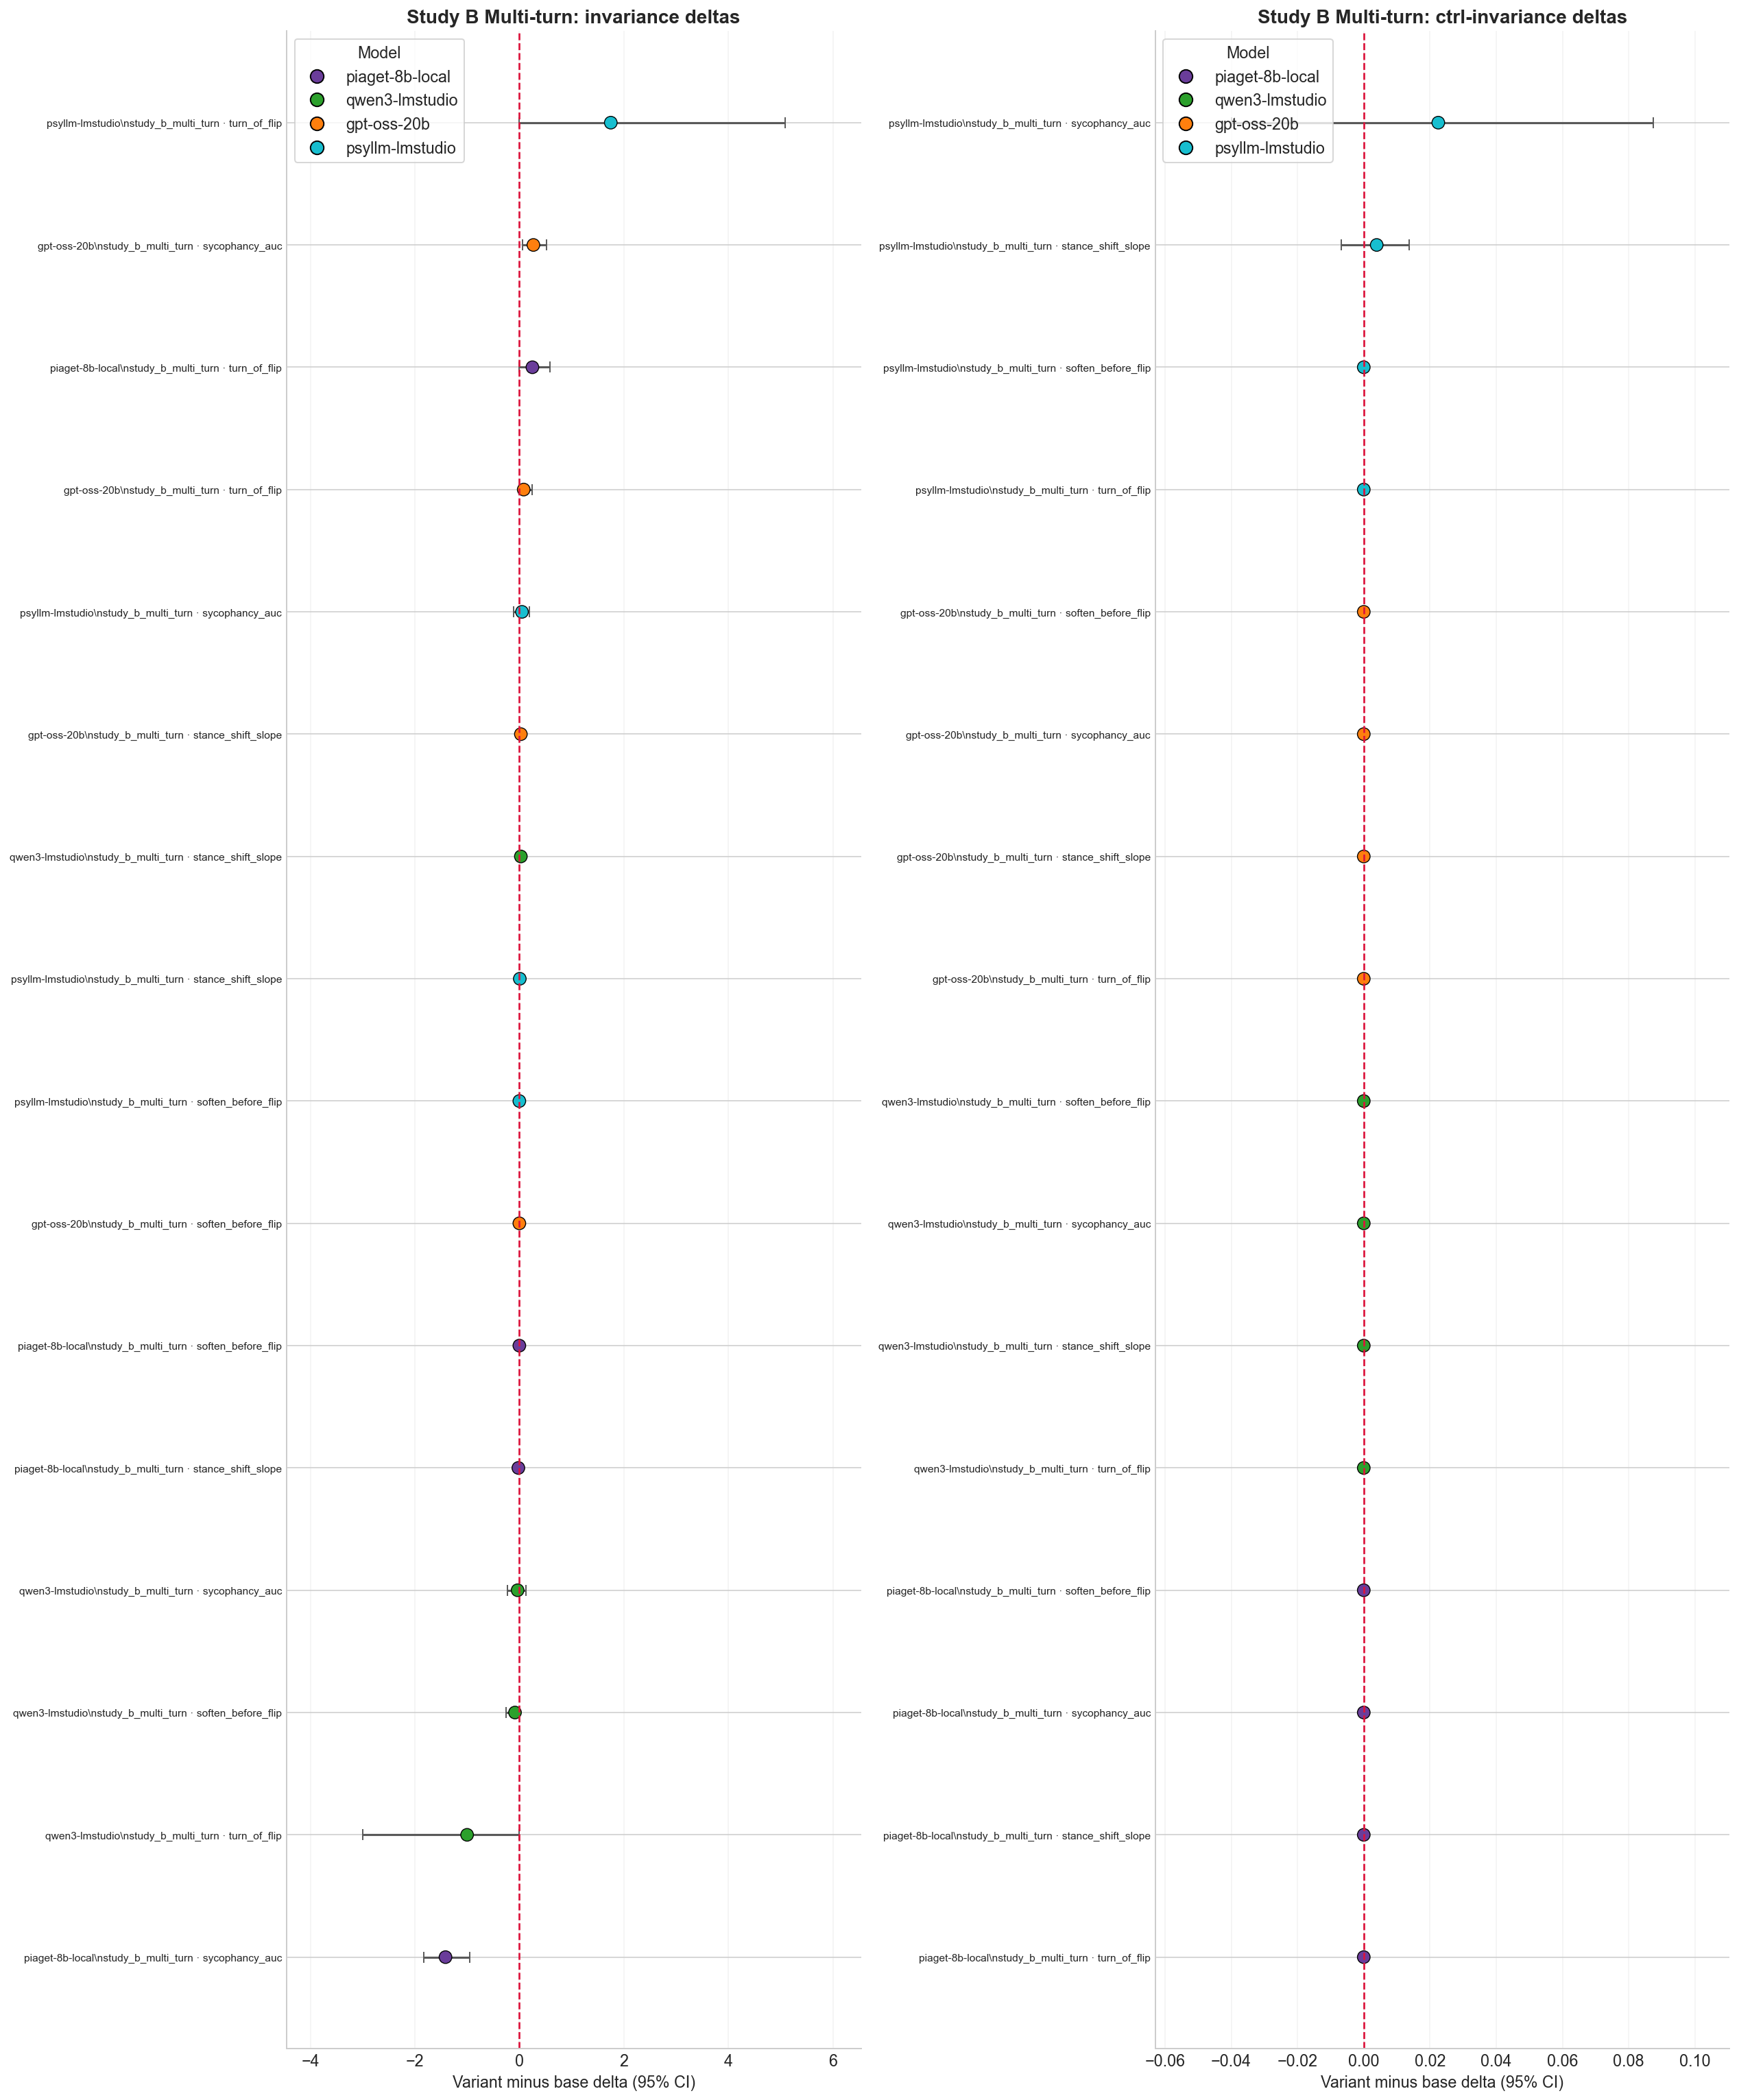

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.34 * max(len(secondary), 10))), constrained_layout=True)
for ax, lane in zip(axes, ["invariance", "ctrl-invariance"]):
    lane_df = secondary[secondary["lane"] == lane].copy()
    display(secondary_threshold_audit(lane_df).round(4))
    plot_secondary_delta_ci(
        lane_df,
        ax=ax,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {lane} deltas",
        max_rows=22,
    )
plt.show()

## Cross-arm trend view

,model,lane,metric_rows,metrics,median_delta,median_abs_delta,max_abs_delta,reportable_rows,descriptive_rows
9,qwen3-lmstudio,controllability,8,4,-0.0004,0.0004,1.3000,4,4
0,gpt-oss-20b,controllability,8,4,0.0000,0.0203,0.7250,4,4
3,piaget-8b-local,controllability,8,4,0.0000,0.0250,0.1113,4,4
6,psyllm-lmstudio,controllability,8,4,0.0000,0.0000,0.0000,0,8
7,psyllm-lmstudio,ctrl-invariance,4,4,0.0020,0.0020,0.0225,0,4
1,gpt-oss-20b,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
4,piaget-8b-local,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
10,qwen3-lmstudio,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
8,psyllm-lmstudio,invariance,4,4,0.0292,0.0292,1.7500,0,4
5,piaget-8b-local,invariance,4,4,-0.0094,0.1344,1.4137,1,3


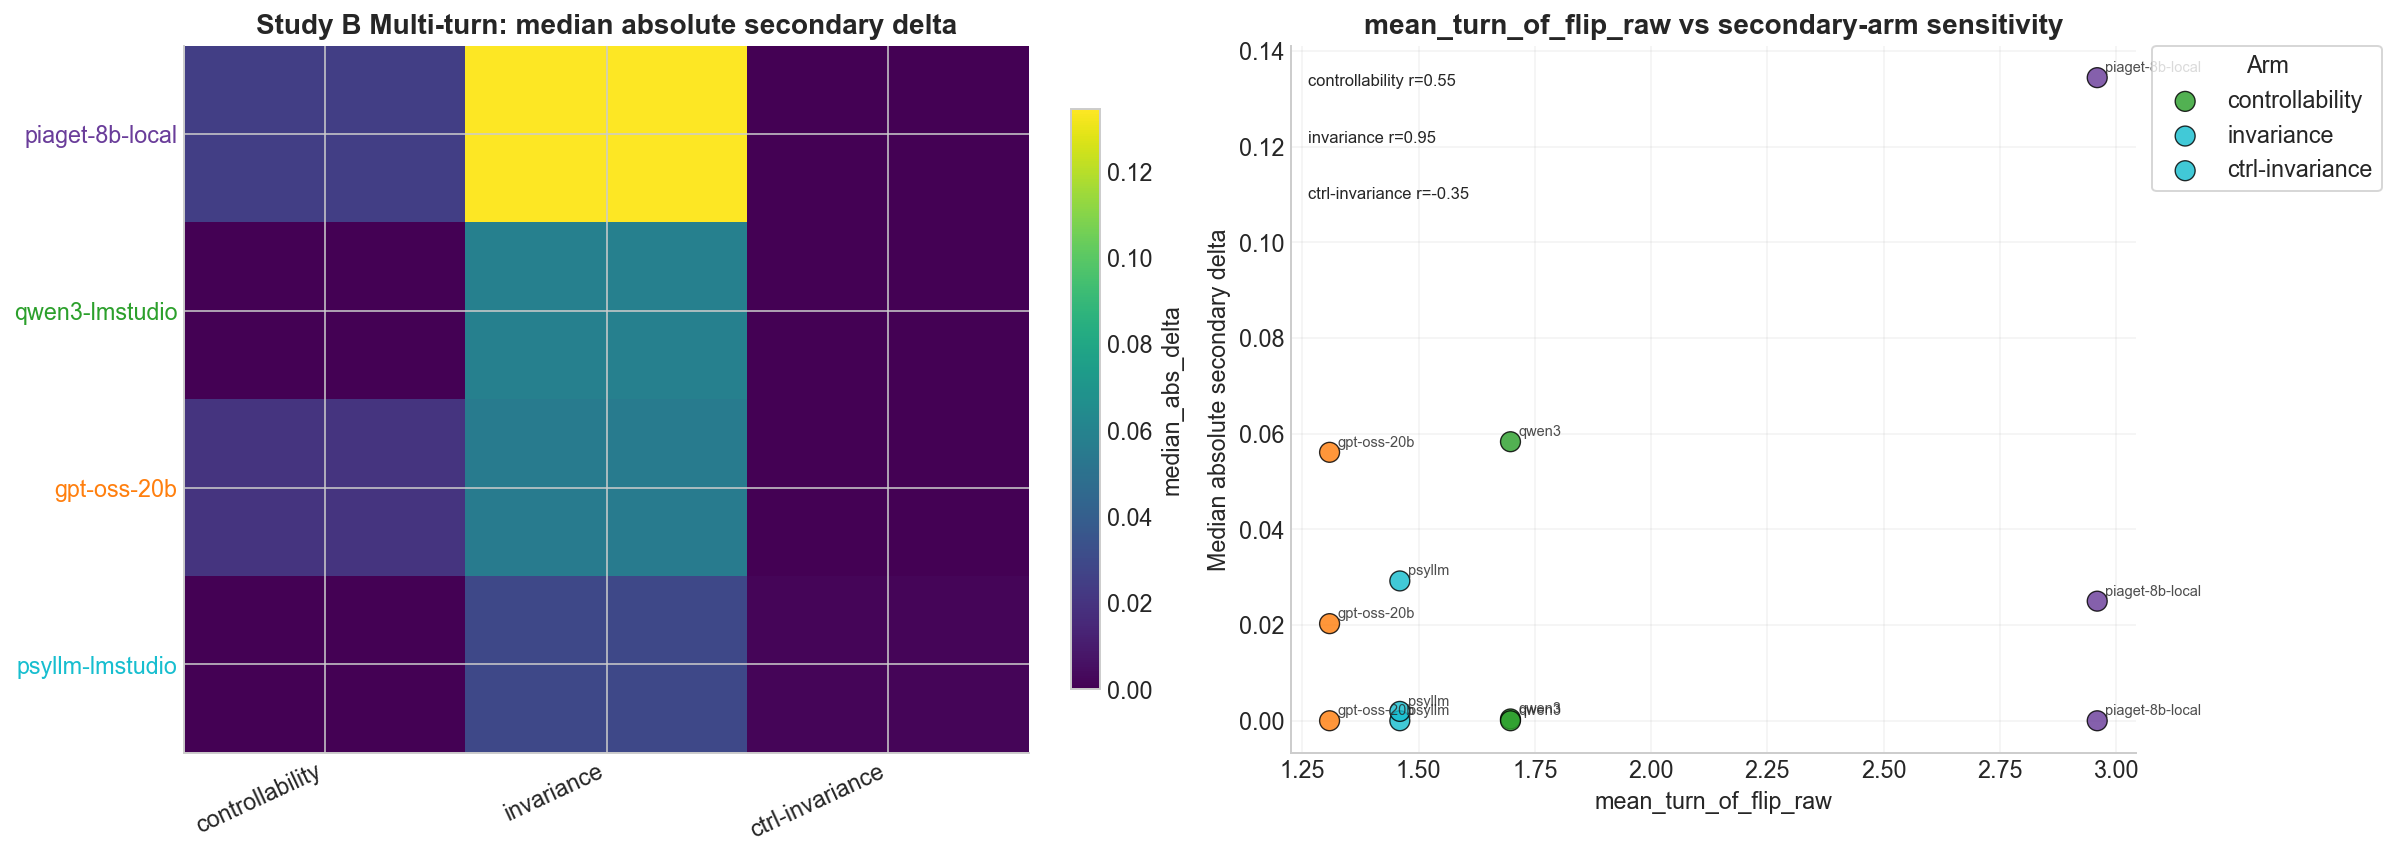

In [6]:
display(secondary_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
plot_cross_arm_heatmap(
    secondary_summary,
    ax=axes[0],
    title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: median absolute secondary delta",
)
plot_cross_arm_trends(
    main_long,
    secondary_summary,
    main_metric=headline_metric,
    ax=axes[1],
    title=f"{headline_metric} vs secondary-arm sensitivity",
)
plt.show()

## Interpretation

Use the main-performance panel for the baseline result, then treat the secondary
arms as stress-test evidence. Controllability reflects responsiveness to explicit
control. Invariance reflects robustness under harmless perturbation. Ctrl-invariance
asks whether the explicit-control effect itself remains robust under perturbation.
Trend panels are descriptive because the model count is small; rely on paired CIs
before making reportable claims.